In [2]:
import sys
from pathlib import Path

# Folder that contains model.py, diffuzz.py, util.py, sst_dataloader.py, etc.
PROJ_DIR = Path("/data/purkislabmingyue/10.141.132.249/purkislab2a/Mingyue/Oahu/CARE-SST-main").resolve()

if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

print("Using imports from:", PROJ_DIR)

Using imports from: /data/purkislabmingyue/10.141.132.249/purkislab2a/Mingyue/Oahu/CARE-SST-main


## debug 1st scene

device: cuda
DATA_DIR: ../../Mozambique_N/result/ready_whole_2020_300
L3S folder: ../../Mozambique_N/result/ready_whole_2020_300/cloud/viirs
OISST folder: ../../Mozambique_N/result/ready_whole_2020_300/cloud/oisst
land mask folder: ../../Mozambique_N/result/ready_whole_2020_300/cloud/land_mask
BALANCE_ALPHA: 1

DIRECT VIIRS CHECK
path: ../../Mozambique_N/result/ready_whole_2020_300/cloud/viirs/20200101.npy
direct viirs shape: (300, 300)
direct viirs min/max: 0.0 30.100006
direct viirs finite: 90000
direct viirs nan: 0

DIRECT OISST CHECK
path: ../../Mozambique_N/result/ready_whole_2020_300/cloud/oisst/20200101.npy
direct oisst shape: (300, 300)
direct oisst min/max: 0.0 29.320007
direct oisst finite: 90000
direct oisst nan: 0

DIRECT LAND_MASK CHECK
path: ../../Mozambique_N/result/ready_whole_2020_300/cloud/land_mask/20200101.npy
direct land_mask shape: (300, 300)
direct land_mask min/max: 0.0 1.0
direct land_mask finite: 90000
direct land_mask nan: 0
direct land unique: [0. 1.]
direct

Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 26.41it/s]


Using DIRECT saved land mask.
valid L3S/OISST balance pixels: 163

===== BALANCE CHECK =====
Before L3S-OISST mean: 0.06693197786808014
Before L3S-OISST std : 0.13213396072387695
Before L3S-OISST min/max: -0.1300048828125 0.360015869140625
After balanced-OISST mean: 0.06693197786808014
After balanced-OISST std : 0.13213396072387695
After balanced-OISST min/max: -0.1300048828125 0.360015869140625


Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 27.11it/s]



===== OUTPUT RANGE CHECK =====
L3S min/max: 28.970001 29.450012
OISST min/max: 28.790009 29.320007
Balanced L3S min/max: 28.970001 29.450012
Original hybrid min/max: 28.862047 29.450012
Balanced hybrid min/max: 28.884485 29.450012


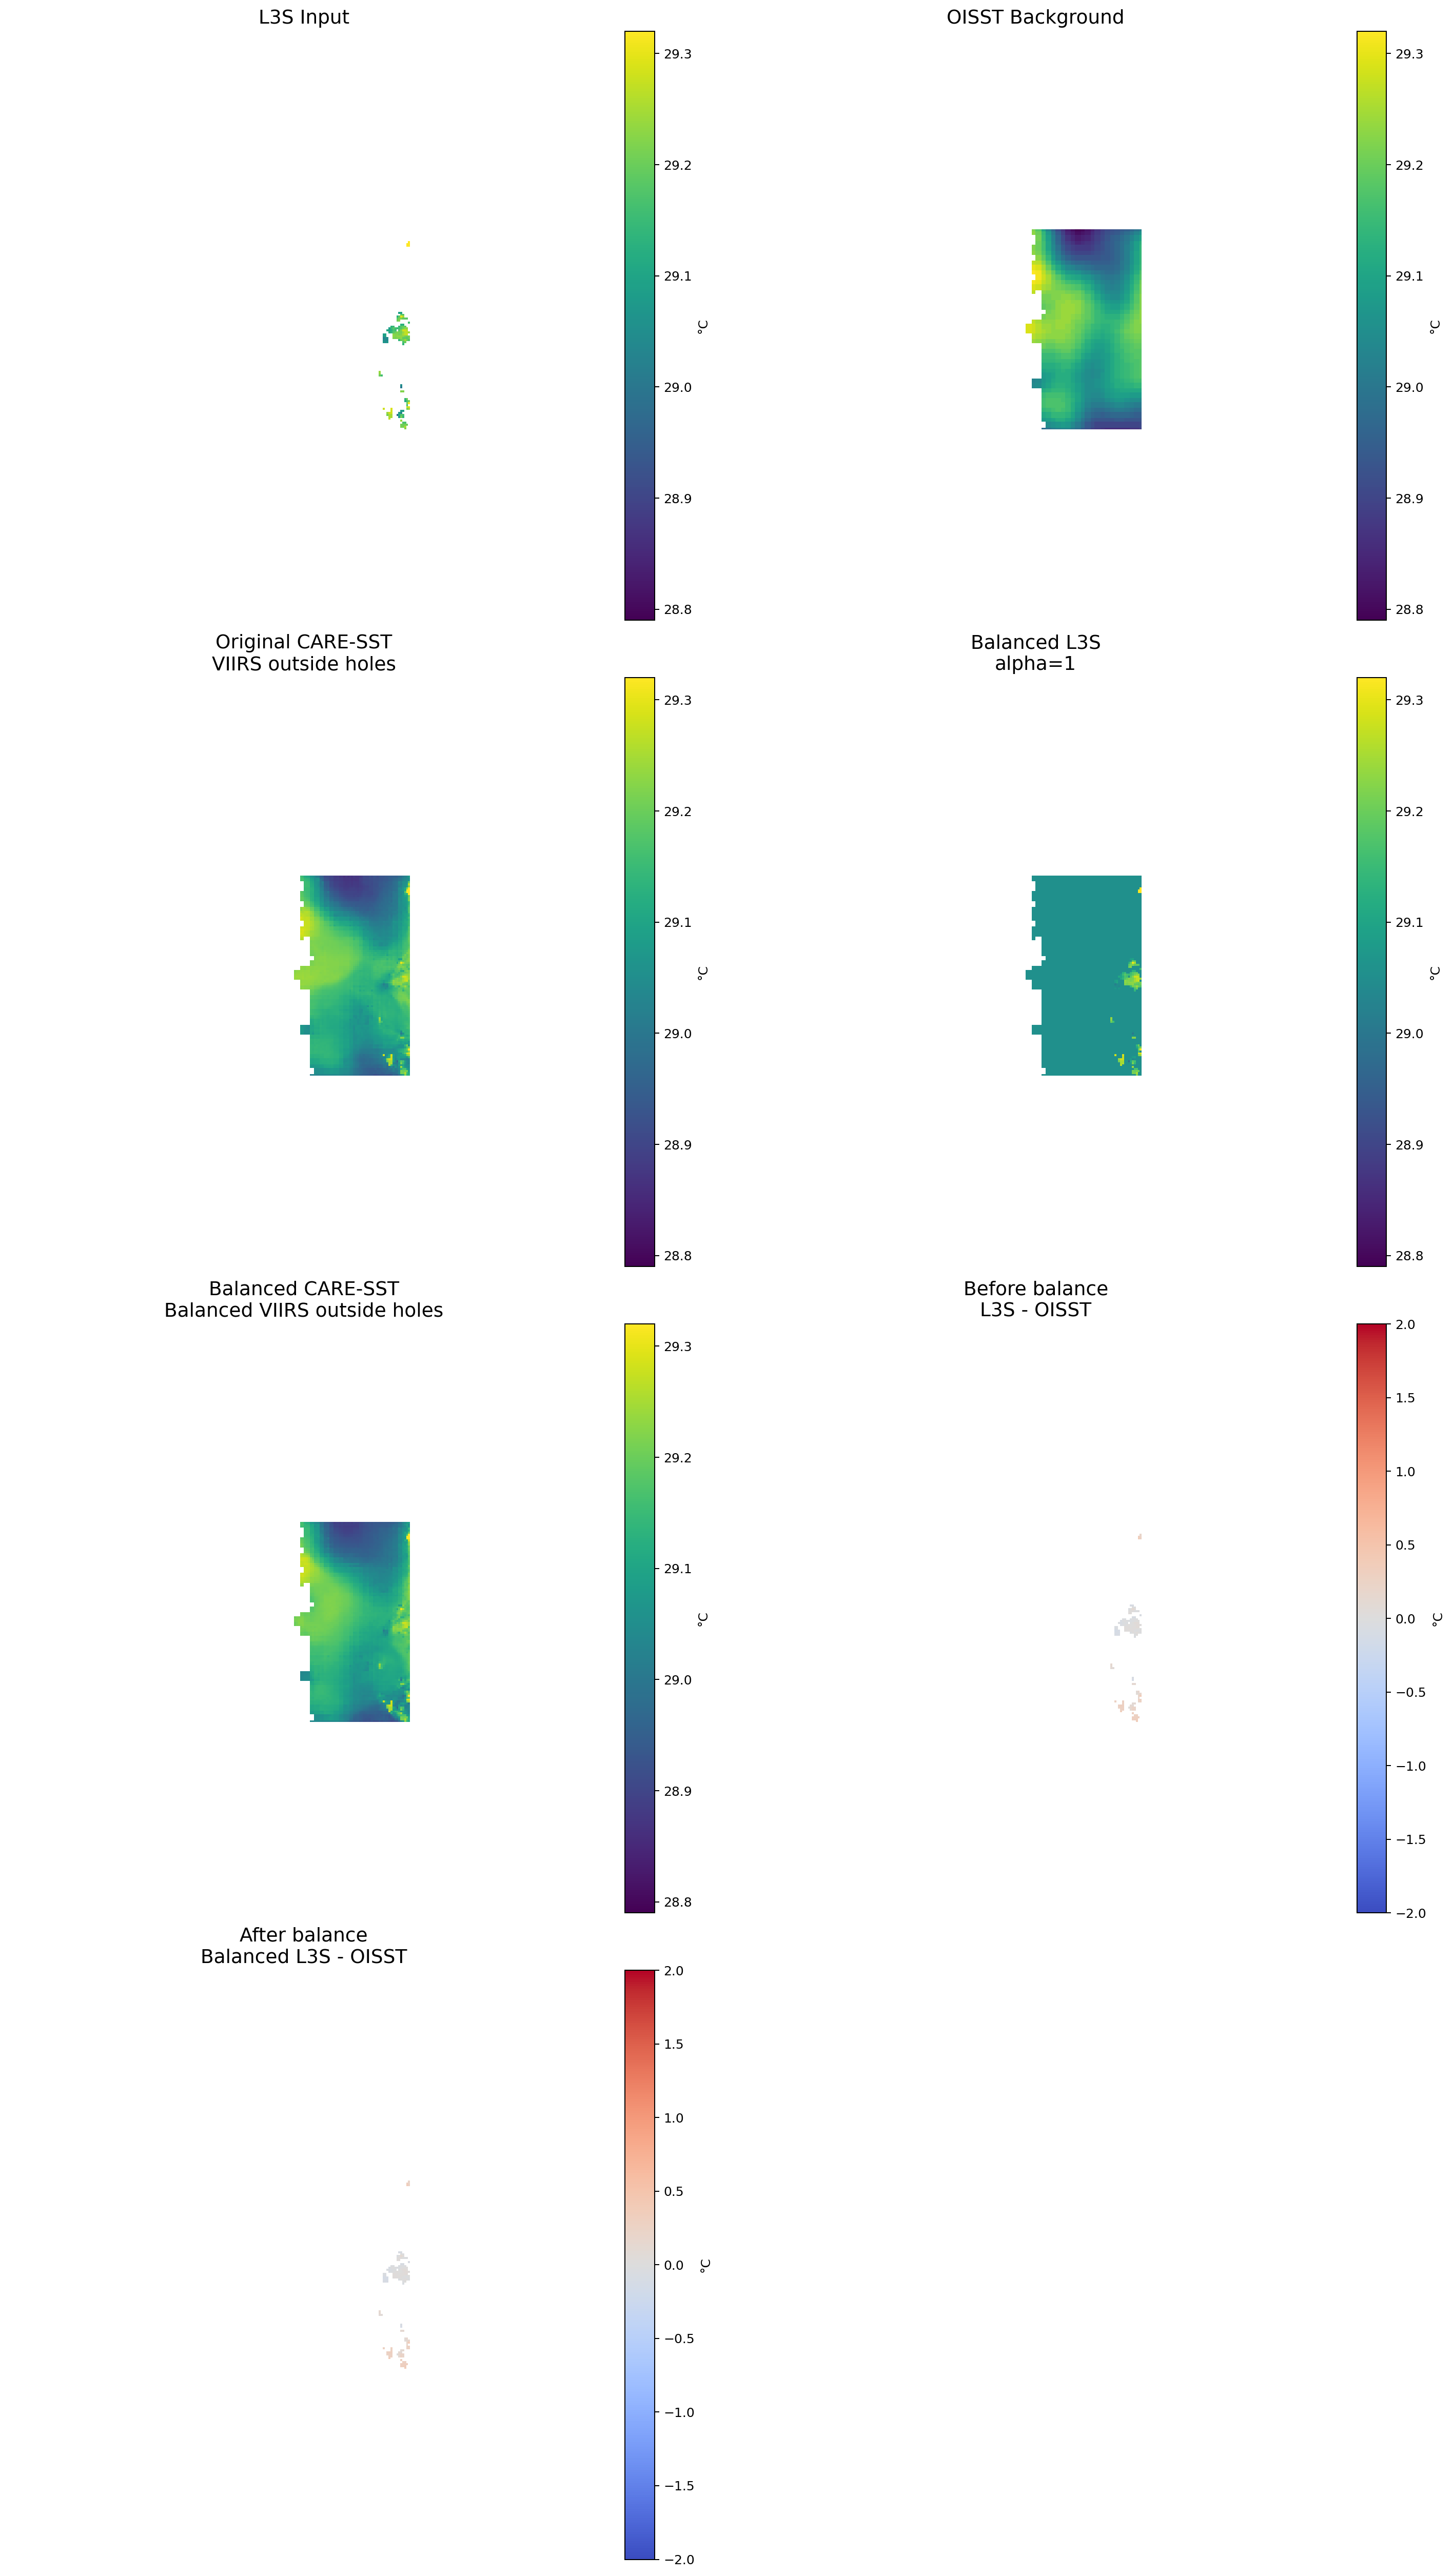

Only plotted the first sample. No files saved.

Done. No outputs were saved.


In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from model import CARE_SST
from diffuzz2 import Diffuzz, EMA
from sst_dataloader2 import Dataset
from util import load

# =========================
# CONFIG
# =========================
ROOT_DIR = "../../Mozambique_N/result"
DATA_DIR = os.path.join(ROOT_DIR, "ready_whole_2020_300")
MODE = "cloud_reconstruction"

WEIGHT_DIR = "../../Oahu/CARE-SST-main"
CKPT_DIR = os.path.join(WEIGHT_DIR, "result", "checkpoint")

INPUT_FOLDER = "viirs"
INPUT_LABEL = "L3S"
SUBFOLDER = "cloud"

BATCH_SIZE = 1
TIMESTEPS = 50
NUM_WORKERS = 0
PLOT_ORIGIN = "lower"

INIT_FROM_BG = True
BG_MIX = 0.12
BG_MIX_TAU = 0.7

ONLY_FIRST_SAMPLE = True
CHECK_DATE = "20200101"

# =========================
# NEW: local VIIRS/OISST balancing
# =========================
BALANCE_ALPHA = 1
# 1.0 = keep original VIIRS
# 0.5 = halfway between VIIRS and OISST
# 0.2 = closer to OISST
# 0.0 = fully replace VIIRS valid pixels with OISST

# =========================
# Reproducibility
# =========================
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# =========================
# Helpers
# =========================
def denorm(x, min_val, max_val):
    return ((x + 1.0) / 2.0) * (max_val - min_val) + min_val


def norm_to_model(x, min_val, max_val):
    x_n = 2.0 * (x - min_val) / (max_val - min_val) - 1.0
    return np.clip(x_n, -1.0, 1.0)


def to_2d_np(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.squeeze(x)


def balance_l3s_to_oisst(l3s, oisst, valid_pixels, alpha=0.5):
    """
    Locally pull L3S/VIIRS valid pixels toward OSTIA.

    alpha = 1.0 -> original L3S
    alpha = 0.5 -> halfway between L3S and OSTIA
    alpha = 0.0 -> exactly OSTIA
    """
    out = l3s.copy()

    out[valid_pixels] = (
        oisst[valid_pixels]
        + alpha * (l3s[valid_pixels] - oisst[valid_pixels])
    )

    return out


def get_loader(folder):
    transform = transforms.Compose([])

    dataset = Dataset(
        viirs_dir=os.path.join(DATA_DIR, SUBFOLDER, folder),
        oisst_dir=os.path.join(DATA_DIR, SUBFOLDER, "oisst"),
        land_mask_dir=os.path.join(DATA_DIR, SUBFOLDER, "land_mask"),
        transform=transform,
        mask_type=MODE,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
    )

    return dataset, loader


def direct_load_npy_by_date(folder, date_str):
    path = Path(DATA_DIR) / SUBFOLDER / folder / f"{date_str}.npy"

    print("\n==============================")
    print(f"DIRECT {folder.upper()} CHECK")
    print("==============================")
    print("path:", path)

    if not path.exists():
        print(f"[WARN] Direct {folder} file not found.")
        return None

    arr = np.load(path)

    print(f"direct {folder} shape:", arr.shape)
    print(f"direct {folder} min/max:", np.nanmin(arr), np.nanmax(arr))
    print(f"direct {folder} finite:", int(np.isfinite(arr).sum()))
    print(f"direct {folder} nan:", int(np.isnan(arr).sum()))

    if folder == "land_mask":
        print("direct land unique:", np.unique(arr))
        print("direct land pixels:", int(np.sum(arr > 0.5)))
        print("direct ocean pixels:", int(np.sum(arr <= 0.5)))

    return arr


def plot_balance_comparison(
    input_img,
    oisst_img,
    original_result,
    balanced_l3s,
    balanced_result,
    diff_before,
    diff_after,
    vmin,
    vmax,
    label="L3S",
):
    fig, axes = plt.subplots(4, 2, figsize=(16, 28), dpi=180)
    axes = axes.ravel()

    panels = [
        (f"{label} Input", input_img, "viridis", vmin, vmax, "°C"),
        ("OISST Background", oisst_img, "viridis", vmin, vmax, "°C"),
        ("Original CARE-SST\nVIIRS outside holes", original_result, "viridis", vmin, vmax, "°C"),
        (f"Balanced {label}\nalpha={BALANCE_ALPHA}", balanced_l3s, "viridis", vmin, vmax, "°C"),
        ("Balanced CARE-SST\nBalanced VIIRS outside holes", balanced_result, "viridis", vmin, vmax, "°C"),
        ("Before balance\nL3S - OISST", diff_before, "coolwarm", -2, 2, "°C"),
        ("After balance\nBalanced L3S - OISST", diff_after, "coolwarm", -2, 2, "°C"),
    ]

    for i, (title, arr, cmap, this_vmin, this_vmax, cbar_label) in enumerate(panels):
        im = axes[i].imshow(
            arr,
            cmap=cmap,
            vmin=this_vmin,
            vmax=this_vmax,
            origin=PLOT_ORIGIN,
        )
        axes[i].set_title(title, fontsize=15)
        axes[i].axis("off")
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label=cbar_label)

    axes[-1].axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# Main
# =========================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    print("DATA_DIR:", DATA_DIR)
    print("L3S folder:", os.path.join(DATA_DIR, SUBFOLDER, INPUT_FOLDER))
    print("OISST folder:", os.path.join(DATA_DIR, SUBFOLDER, "oisst"))
    print("land mask folder:", os.path.join(DATA_DIR, SUBFOLDER, "land_mask"))
    print("BALANCE_ALPHA:", BALANCE_ALPHA)

    direct_viirs = direct_load_npy_by_date("viirs", CHECK_DATE)
    direct_oisst = direct_load_npy_by_date("oisst", CHECK_DATE)
    direct_land_mask = direct_load_npy_by_date("land_mask", CHECK_DATE)

    # -------------------------
    # Load model
    # -------------------------
    netG = CARE_SST().to(device)
    optG = torch.optim.AdamW(netG.parameters(), lr=1e-4)

    diffuzz = Diffuzz(device=device)

    _ = EMA(0.995)
    _ = copy.deepcopy(netG).eval().requires_grad_(False)

    netG, optG, _ = load(
        ckpt_dir=CKPT_DIR,
        netG=netG,
        optG=optG,
    )

    netG.eval()

    # -------------------------
    # Load dataset
    # -------------------------
    dataset, loader = get_loader(INPUT_FOLDER)

    print(f"Total samples found in {INPUT_FOLDER}: {len(dataset)}")

    if len(dataset) == 0:
        print("[ERROR] No samples found.")
        return

    # -------------------------
    # Run CARE-SST
    # -------------------------
    for idx, images in enumerate(loader):
        print(f"\n--- Running sample {idx + 1}/{len(loader)} ---")

        structure = images["structure_image"].to(device)  # OISST background
        gt = images["gt_image"].to(device)                # L3S input
        mask = images["inpaint_map"].to(device)           # holes

        hole = to_2d_np(mask[0, 0]) > 0.5

        land_mask = to_2d_np(images["land_mask"][0])
        dataloader_land_bool = land_mask > 0.5

        oisst_min = float(images["oisst_min"][0].cpu().numpy())
        oisst_max = float(images["oisst_max"][0].cpu().numpy())

        print("oisst_min:", oisst_min)
        print("oisst_max:", oisst_max)
        print("hole pixels:", int(np.sum(hole)))
        print("land pixels:", int(np.sum(dataloader_land_bool)))
        print("ocean pixels:", int(np.sum(~dataloader_land_bool)))

        # =====================================================
        # 1. Original CARE-SST run
        # =====================================================
        with torch.no_grad():
            preds_original = diffuzz.sample(
                model=netG,
                background=structure,
                shape=gt.shape,
                mask=mask,
                x_init=gt,
                sampler="ddpm",
                timesteps=TIMESTEPS,
                init_from_bg=INIT_FROM_BG,
                bg_mix=BG_MIX,
                bg_mix_tau=BG_MIX_TAU,
            )

        # -------------------------
        # Convert normalized data back to Celsius
        # -------------------------
        l3s_n = to_2d_np(gt[0, 0])
        oisst_n = to_2d_np(structure[0, 0])
        caresst_original_n = to_2d_np(preds_original[-1][0])

        l3s = denorm(l3s_n, oisst_min, oisst_max)
        oisst = denorm(oisst_n, oisst_min, oisst_max)
        caresst_original = denorm(caresst_original_n, oisst_min, oisst_max)

        # -------------------------
        # Choose final land mask
        # -------------------------
        if direct_land_mask is not None and direct_land_mask.shape == caresst_original.shape:
            final_land_bool = direct_land_mask > 0.5
            print("Using DIRECT saved land mask.")
        else:
            final_land_bool = dataloader_land_bool
            print("Using DATALOADER land mask.")

        # =====================================================
        # 2. Locally balance valid L3S pixels toward OISST
        # =====================================================
        valid_l3s_pixels = (
            (~hole)
            & (~final_land_bool)
            & np.isfinite(l3s)
            & np.isfinite(oisst)
        )

        print("valid L3S/OISST balance pixels:", int(np.sum(valid_l3s_pixels)))

        diff_before = np.where(valid_l3s_pixels, l3s - oisst, np.nan)

        l3s_balanced = balance_l3s_to_oisst(
            l3s=l3s,
            oisst=oisst,
            valid_pixels=valid_l3s_pixels,
            alpha=BALANCE_ALPHA,
        )

        diff_after = np.where(valid_l3s_pixels, l3s_balanced - oisst, np.nan)

        if np.sum(valid_l3s_pixels) > 0:
            print("\n===== BALANCE CHECK =====")
            print("Before L3S-OISST mean:", float(np.nanmean(diff_before)))
            print("Before L3S-OISST std :", float(np.nanstd(diff_before)))
            print("Before L3S-OISST min/max:",
                  float(np.nanmin(diff_before)),
                  float(np.nanmax(diff_before)))

            print("After balanced-OISST mean:", float(np.nanmean(diff_after)))
            print("After balanced-OISST std :", float(np.nanstd(diff_after)))
            print("After balanced-OISST min/max:",
                  float(np.nanmin(diff_after)),
                  float(np.nanmax(diff_after)))

        # Normalize balanced L3S back to model input space
        gt_balanced_n = norm_to_model(l3s_balanced, oisst_min, oisst_max)
        gt_balanced = torch.from_numpy(gt_balanced_n).float().to(device)
        gt_balanced = gt_balanced[None, None, :, :]

        # =====================================================
        # 3. CARE-SST run with balanced L3S input
        # =====================================================
        with torch.no_grad():
            preds_balanced = diffuzz.sample(
                model=netG,
                background=structure,
                shape=gt.shape,
                mask=mask,
                x_init=gt_balanced,
                sampler="ddpm",
                timesteps=TIMESTEPS,
                init_from_bg=INIT_FROM_BG,
                bg_mix=BG_MIX,
                bg_mix_tau=BG_MIX_TAU,
            )

        caresst_balanced_n = to_2d_np(preds_balanced[-1][0])
        caresst_balanced = denorm(caresst_balanced_n, oisst_min, oisst_max)

        # =====================================================
        # 4. Apply land mask
        # =====================================================
        l3s_masked = np.where(final_land_bool, np.nan, l3s)
        oisst_masked = np.where(final_land_bool, np.nan, oisst)
        l3s_balanced_masked = np.where(final_land_bool, np.nan, l3s_balanced)

        caresst_original_masked = np.where(final_land_bool, np.nan, caresst_original)
        caresst_balanced_masked = np.where(final_land_bool, np.nan, caresst_balanced)

        # Show holes as NaN in input
        l3s_input = l3s_masked.copy()
        l3s_input[hole] = np.nan

        # Original hybrid:
        # valid original L3S outside holes + CARE-SST inside holes
        caresst_original_hybrid = caresst_original_masked.copy()
        caresst_original_hybrid[~hole] = l3s_masked[~hole]
        caresst_original_hybrid = np.where(final_land_bool, np.nan, caresst_original_hybrid)

        # Balanced hybrid:
        # valid balanced L3S outside holes + CARE-SST generated inside holes
        caresst_balanced_hybrid = caresst_balanced_masked.copy()
        caresst_balanced_hybrid[~hole] = l3s_balanced_masked[~hole]
        caresst_balanced_hybrid = np.where(final_land_bool, np.nan, caresst_balanced_hybrid)

        print("\n===== OUTPUT RANGE CHECK =====")
        print("L3S min/max:", np.nanmin(l3s_masked), np.nanmax(l3s_masked))
        print("OISST min/max:", np.nanmin(oisst_masked), np.nanmax(oisst_masked))
        print("Balanced L3S min/max:",
              np.nanmin(l3s_balanced_masked),
              np.nanmax(l3s_balanced_masked))
        print("Original hybrid min/max:",
              np.nanmin(caresst_original_hybrid),
              np.nanmax(caresst_original_hybrid))
        print("Balanced hybrid min/max:",
              np.nanmin(caresst_balanced_hybrid),
              np.nanmax(caresst_balanced_hybrid))

        # =====================================================
        # 5. Plot original + locally balanced result
        # =====================================================
        plot_balance_comparison(
            input_img=l3s_input,
            oisst_img=oisst_masked,
            original_result=caresst_original_hybrid,
            balanced_l3s=l3s_balanced_masked,
            balanced_result=caresst_balanced_hybrid,
            diff_before=diff_before,
            diff_after=diff_after,
            vmin=oisst_min,
            vmax=oisst_max,
            label=INPUT_LABEL,
        )

        if ONLY_FIRST_SAMPLE:
            print("Only plotted the first sample. No files saved.")
            break

    print("\nDone. No outputs were saved.")


if __name__ == "__main__":
    main()

## Run in batch

/home/mingyue/apps/miniforge3/envs/sst/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


device: cuda
ROOT_DIR: ../../Mozambique_S/result
YEARS: [2020]
BALANCE_ALPHA: 1

Loading CARE-SST model...

PROCESSING YEAR 2020
DATA_DIR: ../../Mozambique_S/result/ready_whole_2020_300
SAVE_TIF_DIR: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff
Dataset initialized:
  VIIRS files: 366
  OISST files: 366
  land_mask_dir: ../../Mozambique_S/result/ready_whole_2020_300/cloud/land_mask
  land mask files: 366
Total dataset samples: 366
Total stems: 366
First 5 stems: ['20200101', '20200102', '20200103', '20200104', '20200105']

[1/366] Processing 20200101
hole pixels: 6288
land pixels: 83642
invalid pixels: 0
valid balance pixels: 70


Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.77it/s]


Final balanced hybrid min/max: 29.08224868774414 30.79998779296875


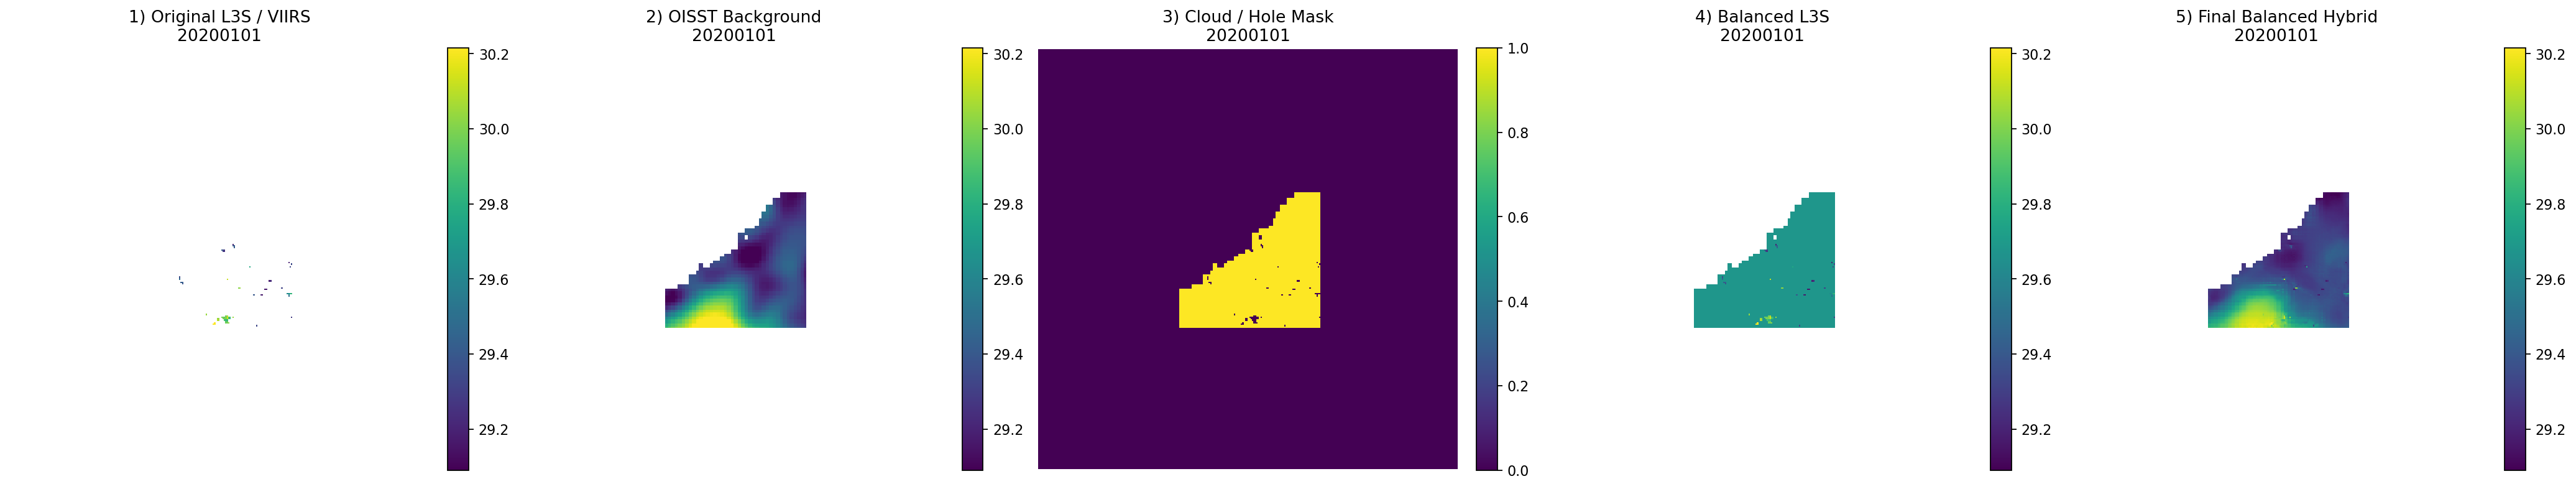

Saved: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20200101.tif

[2/366] Processing 20200102
hole pixels: 6161
land pixels: 83642
invalid pixels: 0
valid balance pixels: 197


Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 27.28it/s]


Final balanced hybrid min/max: 28.529998779296875 30.1199951171875
Saved: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20200102.tif

[3/366] Processing 20200103
hole pixels: 5184
land pixels: 83642
invalid pixels: 0
valid balance pixels: 1174


Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 27.35it/s]


Final balanced hybrid min/max: 28.886459350585938 30.970001220703125
Saved: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20200103.tif

[4/366] Processing 20200104
hole pixels: 4660
land pixels: 83642
invalid pixels: 0
valid balance pixels: 1698


...

Final balanced hybrid min/max: 28.44451141357422 30.920013427734375
Saved: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20201229.tif

[365/366] Processing 20201230
hole pixels: 4209
land pixels: 83642
invalid pixels: 0
valid balance pixels: 2149


Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 26.70it/s]


Final balanced hybrid min/max: 27.867719650268555 30.480010986328125
Saved: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20201230.tif

[366/366] Processing 20201231
hole pixels: 1240
land pixels: 83642
invalid pixels: 0
valid balance pixels: 5118


Sampling Progress: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 27.02it/s]


Final balanced hybrid min/max: 26.656892776489258 30.17999267578125
Saved: ../../Mozambique_S/result/caresst_whole_l3s_2020/geotiff/20201231.tif

Done.
All years finished.


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

import rasterio
from rasterio.transform import from_origin

from model import CARE_SST
from diffuzz2 import Diffuzz, EMA
from sst_dataloader2 import Dataset
from util import load


# =========================================================
# CONFIG
# =========================================================
SITE = "Mozambique_S"
ROOT_DIR = Path(f"../../{SITE}/result")

YEARS = range(2020, 2021)

MODE = "cloud_reconstruction"

WEIGHT_DIR = Path("../../Oahu/CARE-SST-main")
CKPT_DIR = WEIGHT_DIR / "result" / "checkpoint"

INPUT_FOLDER = "viirs"
INPUT_LABEL = "L3S"
SUBFOLDER = "cloud"

BATCH_SIZE = 1
TIMESTEPS = 50
NUM_WORKERS = 0

PLOT_ORIGIN = "lower"
PLOT_FIRST_SCENE = True

INIT_FROM_BG = True
BG_MIX = 0.12
BG_MIX_TAU = 0.7

# 1.0 = keep original VIIRS
# 0.8 = slightly pull VIIRS toward OISST
# 0.0 = fully replace valid VIIRS with OISST
BALANCE_ALPHA = 1

SAVE_NPY = False


# =========================================================
# REPRODUCIBILITY
# =========================================================
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def denorm(x, min_val, max_val):
    return ((x + 1.0) / 2.0) * (max_val - min_val) + min_val


def norm_to_model(x, min_val, max_val):
    x_n = 2.0 * (x - min_val) / (max_val - min_val) - 1.0
    return np.clip(x_n, -1.0, 1.0)


def to_2d_np(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()

    x = np.squeeze(x)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {x.shape}")

    return x


def balance_l3s_to_oisst(l3s, oisst, valid_pixels, alpha=0.8):
    out = l3s.copy()

    out[valid_pixels] = (
        oisst[valid_pixels]
        + alpha * (l3s[valid_pixels] - oisst[valid_pixels])
    )

    return out


def get_loader(data_dir):
    dataset = Dataset(
        viirs_dir=str(data_dir / SUBFOLDER / INPUT_FOLDER),
        oisst_dir=str(data_dir / SUBFOLDER / "oisst"),
        land_mask_dir=str(data_dir / SUBFOLDER / "land_mask"),
        transform=transforms.Compose([]),
        mask_type=MODE,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
    )

    return dataset, loader


def get_sorted_file_stems(data_dir):
    viirs_dir = data_dir / SUBFOLDER / INPUT_FOLDER
    files = sorted(viirs_dir.glob("*.npy"))
    return [f.stem for f in files]


def load_real_land_mask(data_dir, stem):
    land_path = data_dir / SUBFOLDER / "land_mask" / f"{stem}.npy"

    if not land_path.exists():
        raise FileNotFoundError(f"Missing land mask: {land_path}")

    return np.load(land_path).astype(np.float32)


def load_lonlat(data_dir, stem):
    lonlat_path = data_dir / SUBFOLDER / "lon_lat" / "viirs" / f"{stem}.npy"

    if not lonlat_path.exists():
        raise FileNotFoundError(f"Missing lon/lat file: {lonlat_path}")

    return np.load(lonlat_path).astype(np.float32)


def make_land_invalid_bool(land_mask):
    land_bool = np.isfinite(land_mask) & (land_mask == 1)
    invalid_bool = np.isfinite(land_mask) & (land_mask < 0)
    return land_bool, invalid_bool


def build_transform_from_lonlat(lonlat):
    lon = lonlat[..., 0]
    lat = lonlat[..., 1]

    valid = np.isfinite(lon) & np.isfinite(lat)

    if np.sum(valid) == 0:
        raise ValueError("No valid lon/lat values found.")

    lon_valid = lon[valid]
    lat_valid = lat[valid]

    h, w = lon.shape

    west = float(np.nanmin(lon_valid))
    east = float(np.nanmax(lon_valid))
    south = float(np.nanmin(lat_valid))
    north = float(np.nanmax(lat_valid))

    dx = (east - west) / max(w - 1, 1)
    dy = (north - south) / max(h - 1, 1)

    transform = from_origin(
        west - dx / 2.0,
        north + dy / 2.0,
        dx,
        dy,
    )

    return transform


def save_geotiff(arr, lonlat, out_path):
    h, w = arr.shape
    transform = build_transform_from_lonlat(lonlat)

    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=h,
        width=w,
        count=1,
        dtype="float32",
        crs="EPSG:4326",
        transform=transform,
        nodata=np.nan,
        compress="deflate",
    ) as dst:
        dst.write(arr.astype(np.float32), 1)


def robust_vmin_vmax(*arrays, p_low=1, p_high=99):
    vals = []

    for arr in arrays:
        if arr is None:
            continue

        arr = np.asarray(arr)
        good = arr[np.isfinite(arr)]

        if good.size > 0:
            vals.append(good)

    if len(vals) == 0:
        return 0.0, 1.0

    vals = np.concatenate(vals)
    return np.nanpercentile(vals, p_low), np.nanpercentile(vals, p_high)


def plot_first_debug(
    stem,
    l3s_input,
    oisst,
    l3s_balanced,
    caresst_balanced_hybrid,
    hole,
    land_mask,
):
    vmin, vmax = robust_vmin_vmax(
        l3s_input,
        oisst,
        l3s_balanced,
        caresst_balanced_hybrid,
    )

    fig, axes = plt.subplots(1, 5, figsize=(26, 5), dpi=160)

    panels = [
        ("1) Original L3S / VIIRS", l3s_input),
        ("2) OISST Background", oisst),
        ("3) Cloud / Hole Mask", hole.astype(float)),
        ("4) Balanced L3S", l3s_balanced),
        ("5) Final Balanced Hybrid", caresst_balanced_hybrid),
    ]

    for ax, (title, arr) in zip(axes, panels):
        if "Mask" in title:
            im = ax.imshow(
                arr,
                origin=PLOT_ORIGIN,
                interpolation="nearest",
            )
        else:
            im = ax.imshow(
                arr,
                origin=PLOT_ORIGIN,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )

        ax.set_title(f"{title}\n{stem}", fontsize=12)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("device:", device)
    print("ROOT_DIR:", ROOT_DIR)
    print("YEARS:", list(YEARS))
    print("BALANCE_ALPHA:", BALANCE_ALPHA)

    # =====================================================
    # Load CARE-SST model once
    # =====================================================
    print("\nLoading CARE-SST model...")

    netG = CARE_SST().to(device)
    optG = torch.optim.AdamW(netG.parameters(), lr=1e-4)

    diffuzz = Diffuzz(device=device)

    _ = EMA(0.995)
    _ = copy.deepcopy(netG).eval().requires_grad_(False)

    netG, optG, _ = load(
        ckpt_dir=str(CKPT_DIR),
        netG=netG,
        optG=optG,
    )

    netG.eval()

    # =====================================================
    # Loop years
    # =====================================================
    for year in YEARS:
        data_dir = ROOT_DIR / f"ready_whole_{year}_300"

        save_root = ROOT_DIR / f"caresst_whole_l3s_{year}"
        save_tif_dir = save_root / "geotiff"
        save_tif_dir.mkdir(parents=True, exist_ok=True)

        save_npy_dir = save_root / "npy"
        if SAVE_NPY:
            save_npy_dir.mkdir(parents=True, exist_ok=True)

        print("\n" + "=" * 80)
        print(f"PROCESSING YEAR {year}")
        print("DATA_DIR:", data_dir)
        print("SAVE_TIF_DIR:", save_tif_dir)
        print("=" * 80)

        if not data_dir.exists():
            print(f"[WARN] Missing data directory, skip year {year}: {data_dir}")
            continue

        dataset, loader = get_loader(data_dir)
        stems = get_sorted_file_stems(data_dir)

        print("Total dataset samples:", len(dataset))
        print("Total stems:", len(stems))
        print("First 5 stems:", stems[:5])

        if len(dataset) == 0:
            print(f"[WARN] No samples found for {year}. Skip.")
            continue

        if len(dataset) != len(stems):
            print("[WARN] Dataset length and stem count differ.")
            print("dataset:", len(dataset))
            print("stems:", len(stems))

        # =================================================
        # Loop all scenes in this year
        # =================================================
        for idx, images in enumerate(loader):
            stem = stems[idx] if idx < len(stems) else f"sample_{idx:04d}"

            print(f"\n[{idx + 1}/{len(loader)}] Processing {stem}")

            structure = images["structure_image"].to(device)
            gt = images["gt_image"].to(device)
            mask = images["inpaint_map"].to(device)

            hole = to_2d_np(mask[0, 0]) > 0.5

            oisst_min = float(images["oisst_min"][0].cpu().numpy())
            oisst_max = float(images["oisst_max"][0].cpu().numpy())

            # ---------------------------------------------
            # Convert normalized input back to Celsius
            # ---------------------------------------------
            l3s_n = to_2d_np(gt[0, 0])
            oisst_n = to_2d_np(structure[0, 0])

            l3s = denorm(l3s_n, oisst_min, oisst_max)
            oisst = denorm(oisst_n, oisst_min, oisst_max)

            # ---------------------------------------------
            # Load real land mask
            # ---------------------------------------------
            real_land_mask = load_real_land_mask(data_dir, stem)
            land_bool, invalid_bool = make_land_invalid_bool(real_land_mask)

            print("hole pixels:", int(np.sum(hole)))
            print("land pixels:", int(np.sum(land_bool)))
            print("invalid pixels:", int(np.sum(invalid_bool)))

            # ---------------------------------------------
            # Balance valid VIIRS/L3S pixels toward OISST
            # Only balance non-hole, ocean, valid pixels
            # ---------------------------------------------
            valid_l3s_pixels = (
                (~hole)
                & (~land_bool)
                & (~invalid_bool)
                & np.isfinite(l3s)
                & np.isfinite(oisst)
            )

            print("valid balance pixels:", int(np.sum(valid_l3s_pixels)))

            l3s_balanced = balance_l3s_to_oisst(
                l3s=l3s,
                oisst=oisst,
                valid_pixels=valid_l3s_pixels,
                alpha=BALANCE_ALPHA,
            )

            # Normalize balanced L3S back to model input space
            gt_balanced_n = norm_to_model(
                l3s_balanced,
                oisst_min,
                oisst_max,
            )

            gt_balanced = torch.from_numpy(gt_balanced_n).float().to(device)
            gt_balanced = gt_balanced[None, None, :, :]

            # ---------------------------------------------
            # Run CARE-SST with balanced L3S input
            # ---------------------------------------------
            with torch.no_grad():
                preds_balanced = diffuzz.sample(
                    model=netG,
                    background=structure,
                    shape=gt.shape,
                    mask=mask,
                    x_init=gt_balanced,
                    sampler="ddpm",
                    timesteps=TIMESTEPS,
                    init_from_bg=INIT_FROM_BG,
                    bg_mix=BG_MIX,
                    bg_mix_tau=BG_MIX_TAU,
                )

            caresst_balanced_n = to_2d_np(preds_balanced[-1][0])
            caresst_balanced = denorm(
                caresst_balanced_n,
                oisst_min,
                oisst_max,
            )

            # =================================================
            # FINAL PRODUCT
            # balanced CARE-SST inside holes
            # balanced VIIRS outside holes
            # land / invalid pixels set to NaN
            # =================================================
            caresst_balanced_hybrid = caresst_balanced.copy()

            # Outside cloud holes, preserve balanced VIIRS
            caresst_balanced_hybrid[~hole] = l3s_balanced[~hole]

            # Mask land and invalid area
            caresst_balanced_hybrid[land_bool] = np.nan
            caresst_balanced_hybrid[invalid_bool] = np.nan

            print(
                "Final balanced hybrid min/max:",
                float(np.nanmin(caresst_balanced_hybrid)),
                float(np.nanmax(caresst_balanced_hybrid)),
            )

            # ---------------------------------------------
            # Plot only first scene of each year
            # ---------------------------------------------
            if idx == 0 and PLOT_FIRST_SCENE:
                l3s_input = l3s.copy()
                l3s_input[hole] = np.nan
                l3s_input[land_bool] = np.nan
                l3s_input[invalid_bool] = np.nan

                l3s_balanced_show = l3s_balanced.copy()
                l3s_balanced_show[land_bool] = np.nan
                l3s_balanced_show[invalid_bool] = np.nan

                oisst_show = oisst.copy()
                oisst_show[land_bool] = np.nan
                oisst_show[invalid_bool] = np.nan

                plot_first_debug(
                    stem=stem,
                    l3s_input=l3s_input,
                    oisst=oisst_show,
                    l3s_balanced=l3s_balanced_show,
                    caresst_balanced_hybrid=caresst_balanced_hybrid,
                    hole=hole,
                    land_mask=real_land_mask,
                )

            # ---------------------------------------------
            # Save GeoTIFF
            # ---------------------------------------------
            lonlat = load_lonlat(data_dir, stem)

            out_tif = save_tif_dir / f"{stem}.tif"

            save_geotiff(
                caresst_balanced_hybrid,
                lonlat,
                out_tif,
            )

            if SAVE_NPY:
                out_npy = save_npy_dir / f"{stem}.npy"
                np.save(
                    out_npy,
                    caresst_balanced_hybrid.astype(np.float32),
                )

            print("Saved:", out_tif)

    print("\nDone.")
    print("All years finished.")


if __name__ == "__main__":
    main()